Processing all samples with bbox generation + gaze mapping
Processing all samples with bbox generation + gaze mapping


2026-09-27 21:52:38,969 - tobii_pytracker.datasets.custom_dataset - WARNING - No valid custom bbox model found in config; using fallback detector (superpixel). Error: "Invalid or missing model configuration: 'bbox_model'"


Found 3 samples with gaze data

Processing sample 1/3: 20260915_115512, slide 0
  Gaze points: 1545
  Saliency skipped: module 'cv2' has no attribute 'saliency'
  superpixel: 26 bboxes
  grid: 9 bboxes


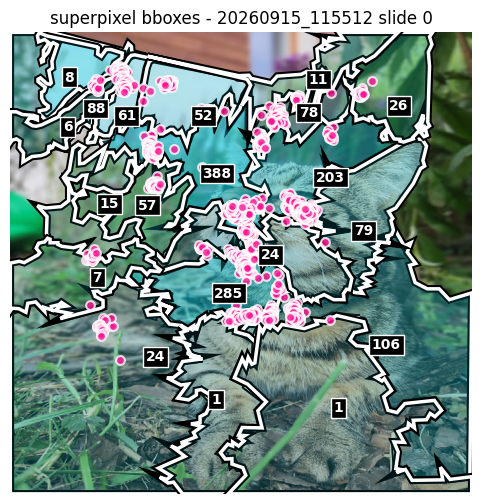

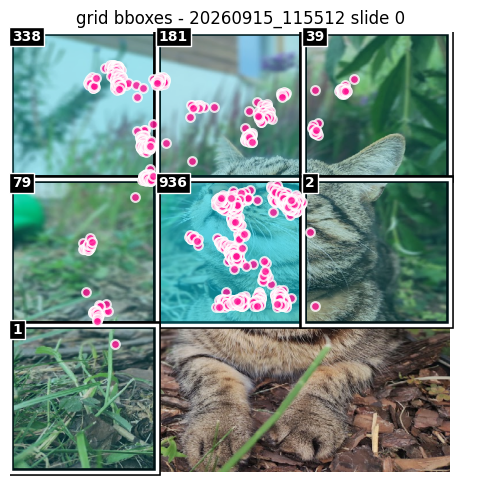


  Results for 20260915_115512, slide 0:


,method,generated_bbox_count,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,attended_bboxes,attended_bbox_ratio
1,grid,9,1545,1576,1545,1.000000,1.020065,7,0.777778
0,superpixel,26,1545,1520,1510,0.977346,1.006623,20,0.769231



Processing sample 2/3: 20260915_115512, slide 1
  Gaze points: 1811
  Saliency skipped: module 'cv2' has no attribute 'saliency'
  superpixel: 24 bboxes
  grid: 9 bboxes


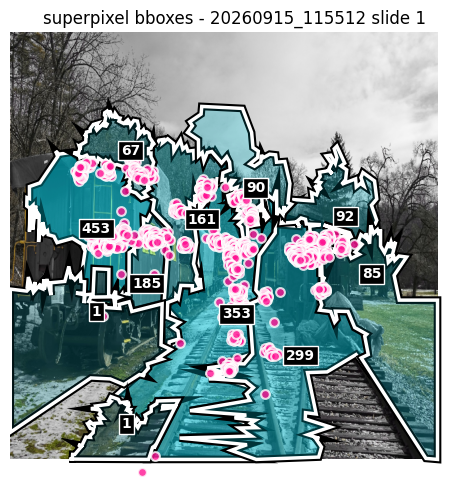

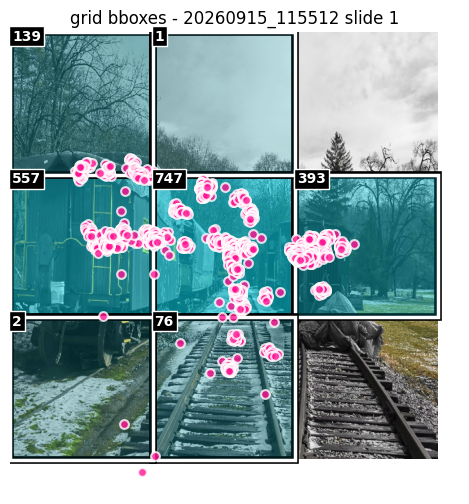


  Results for 20260915_115512, slide 1:


,method,generated_bbox_count,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,attended_bboxes,attended_bbox_ratio
1,grid,9,1811,1915,1810,0.999448,1.058011,7,0.777778
0,superpixel,24,1811,1787,1776,0.980674,1.006194,11,0.458333



Processing sample 3/3: 20260915_115512, slide 2
  Gaze points: 1531
  Saliency skipped: module 'cv2' has no attribute 'saliency'
  superpixel: 21 bboxes
  grid: 9 bboxes


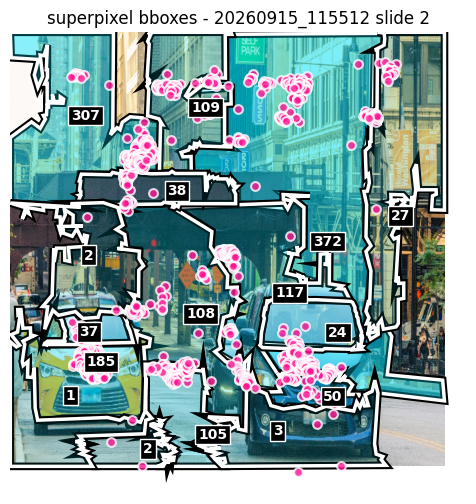

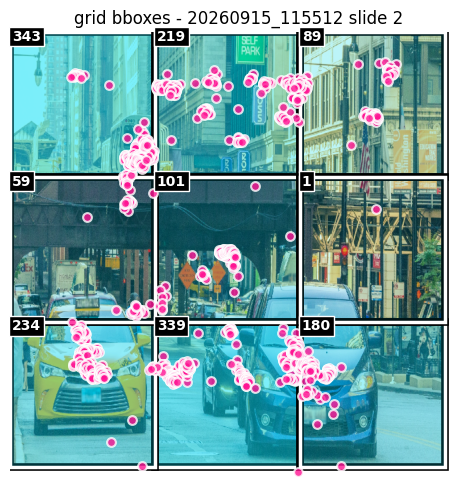


  Results for 20260915_115512, slide 2:


,method,generated_bbox_count,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,attended_bboxes,attended_bbox_ratio
1,grid,9,1531,1565,1530,0.999347,1.022876,9,1.000000
0,superpixel,21,1531,1487,1470,0.960157,1.011565,16,0.761905


Overall Summary across all 3 samples:


,method,generated_bbox_count,total_gaze_points,bbox_hit_count,unique_gaze_hit_count,coverage_by_bboxes,overlap_factor,attended_bboxes,attended_bbox_ratio
0,grid,9.000000,4887,5056,4885,0.999598,1.033651,7.666667,0.851852
1,superpixel,23.666667,4887,4794,4756,0.972726,1.008127,15.666667,0.663156



✓ Processed 6 method-sample combinations
✓ Saved plots to: analysis_outputs/bbox_all_samples

Done


In [1]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig
from tobii_pytracker.datasets.custom_dataset import ImageDataset
from tobii_pytracker.analyze.models import BBoxAttentionAnalyzer

from pathlib import Path
import pandas as pd
import os
from IPython.display import display
from analyze.bbox.demo_context import setup_context
from analyze.bbox.demo_context import set_up_background_input
from analyze.bbox.demo_context import set_up_bbox_method_context
config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')
print('Processing all samples with bbox generation + gaze mapping')

gaze_data, candidate_rows, output_dir = setup_context()
bbox_analyzer = BBoxAttentionAnalyzer(output_folder=output_dir,
                                      config=CustomConfig("../configs/config.yaml")
                                      )
os.chdir(Path.cwd().parent)
dataset = ImageDataset(config=config, calculate_bboxes=False)
all_comparison_rows = []

for idx, selected_raw in candidate_rows.iterrows():
    set_name = str(selected_raw['set_name'])
    slide_index = int(selected_raw['slide_index'])
    print(f'\nProcessing sample {idx + 1}/{len(candidate_rows)}: {set_name}, slide {slide_index}')
    selected_gaze = gaze_data[(gaze_data['set_name'] == set_name) & (gaze_data['slide_index'] == slide_index)].copy()
    if selected_gaze.empty:
        print(f'  WARNING: No gaze data found, skipping')
        continue
    screenshot_path = Path(loader.root) / str(selected_raw['screenshot_file'])
    if not screenshot_path.exists():
        screenshot_path = Path(str(selected_raw['screenshot_file']))
    if not screenshot_path.exists():
        print(f'  WARNING: Screenshot not found: {screenshot_path}, skipping')
        continue
    input_image_path = Path(loader.root) / str(selected_raw['input_data'])
    if not input_image_path.exists():
        input_image_path = Path(str(selected_raw['input_data']))
    if not input_image_path.exists():
        print(f'  WARNING: Input image not found: {input_image_path}, skipping')
        continue
    print(f'  Gaze points: {len(selected_gaze)}')

    generated_by_method, method = set_up_bbox_method_context(dataset, input_image_path)
    sample_comparison_rows = []
    saved_plots = {}
    for method, method_bboxes in generated_by_method.items():
        background_data = set_up_background_input(selected_raw, selected_gaze, method_bboxes)
        scores = bbox_analyzer.analyze(
            background_data=background_data
        )
        if scores.empty:
            print(f'  WARNING: no scores for {method}')
            continue
        evaluation = bbox_analyzer.evaluate(scores)
        if evaluation.empty:
            print(f'  WARNING: no evaluation for {method}')
            continue

        row = evaluation.iloc[0].to_dict()
        row['method'] = method
        row['generated_bbox_count'] = len(method_bboxes)
        row['sample_set_name'] = set_name
        row['sample_slide_index'] = slide_index
        sample_comparison_rows.append(row)
        all_comparison_rows.append(row)

        plot_path = output_dir / f'{set_name}_slide_{slide_index}_{method}.png'
        bbox_analyzer.plot_analysis(
            scored_bboxes=scores,
            gaze_data=selected_gaze,
            screenshot_path=screenshot_path,
            set_name=set_name,
            slide_index=slide_index,
            top_k=25,
            min_hits=1,
            title=f'{method} bboxes - {set_name} slide {slide_index}',
            save_path=plot_path,
        )
        saved_plots[method] = plot_path

    if sample_comparison_rows:
        sample_comparison = pd.DataFrame(sample_comparison_rows)
        print(f'\n  Results for {set_name}, slide {slide_index}:')
        display(sample_comparison[['method', 'generated_bbox_count', 'total_gaze_points', 'bbox_hit_count', 'unique_gaze_hit_count', 'coverage_by_bboxes', 'overlap_factor', 'attended_bboxes', 'attended_bbox_ratio']].sort_values('coverage_by_bboxes', ascending=False))

if all_comparison_rows:
    print(f'Overall Summary across all {len(candidate_rows)} samples:')
    all_comparison = pd.DataFrame(all_comparison_rows)

    summary = all_comparison.groupby('method').agg({
        'generated_bbox_count': 'mean',
        'total_gaze_points': 'sum',
        'bbox_hit_count': 'sum',
        'unique_gaze_hit_count': 'sum',
        'coverage_by_bboxes': 'mean',
        'overlap_factor': 'mean',
        'attended_bboxes': 'mean',
        'attended_bbox_ratio': 'mean',
    }).reset_index()
    
    display(summary.sort_values('coverage_by_bboxes', ascending=False))
    
    print(f'\n✓ Processed {len(all_comparison_rows)} method-sample combinations')
    print(f'✓ Saved plots to: {output_dir}')
else:
    print('WARNING: No valid results were generated')

print('\nDone')